In [11]:


import numpy as np
import torch
from torch.utils.data import TensorDataset,DataLoader,Dataset
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
import torch.nn as nn
from torch import optim
#from scipy.io import loadmat
print("کرنل و کتابخانه‌ها درست کار می‌کنند ✅")










کرنل و کتابخانه‌ها درست کار می‌کنند ✅


In [12]:
# ================================
# Load & Segment Bonn EEG Dataset
# ================================

import os
import numpy as np

def load_signals_from_folder(folder_path):
    signals = []
    for file in sorted(os.listdir(folder_path)):
        if file.endswith(".txt"):   # فقط فایل متنی
            sig = np.loadtxt(os.path.join(folder_path, file))
            signals.append(sig)
    return signals

def segment_signal(signal, seg_len=400, step=200):
    segments = []
    for start in range(0, len(signal) - seg_len, step):
        segments.append(signal[start:start+seg_len])
    return segments

# مسیر پوشه‌ها (دقیقاً داخل پروژه)
signals_Z = load_signals_from_folder("Z")
signals_O = load_signals_from_folder("O")
signals_S = load_signals_from_folder("S")

X = []
y = []

for sig in signals_Z:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(0)

for sig in signals_O:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(1)

for sig in signals_S:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(2)

X = np.array(X)
y = np.array(y)

print("X shape before reshape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))



X shape before reshape: (5700, 400)
Labels: (array([0, 1, 2]), array([1900, 1900, 1900]))


In [13]:
# ===== prepare data for LSTM =====
from sklearn.model_selection import train_test_split

data = X        # همونی که ساختی
target = y

# train / test
Xtrain, Xtest, ytrain, ytest = train_test_split(
    data, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

# train / validation
Xtrain, Xvalid, ytrain, yvalid = train_test_split(
    Xtrain, ytrain,
    test_size=0.15,
    random_state=42,
    stratify=ytrain
)

print("Train:", Xtrain.shape)
print("Valid:", Xvalid.shape)
print("Test :", Xtest.shape)



Train: (3876, 400)
Valid: (684, 400)
Test : (1140, 400)


In [14]:
# reshape درست برای LSTM
Xtrain = Xtrain.reshape(-1, 400, 1)  # samples, seq_len, input_size
Xvalid = Xvalid.reshape(-1, 400, 1)
Xtest  = Xtest.reshape(-1, 400, 1)

print("Xtrain shape:", Xtrain.shape)
print("Xvalid shape:", Xvalid.shape)
print("Xtest shape :", Xtest.shape)


Xtrain shape: (3876, 400, 1)
Xvalid shape: (684, 400, 1)
Xtest shape : (1140, 400, 1)


In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32)
ytrain_tensor = torch.tensor(ytrain, dtype=torch.long)

Xvalid_tensor = torch.tensor(Xvalid, dtype=torch.float32)
yvalid_tensor = torch.tensor(yvalid, dtype=torch.long)

Xtest_tensor  = torch.tensor(Xtest,  dtype=torch.float32)
ytest_tensor  = torch.tensor(ytest,  dtype=torch.long)

train_ds = TensorDataset(Xtrain_tensor, ytrain_tensor)
valid_ds = TensorDataset(Xvalid_tensor, yvalid_tensor)
test_ds  = TensorDataset(Xtest_tensor,  ytest_tensor)

batch_size = 64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print("DataLoader OK ✅")



DataLoader OK ✅


In [16]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,      # ← درست
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(128*2, 3)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = RNNClassifier()
print("Model ready ✅")


Model ready ✅


In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss & Optimizer ready ✅")


Loss & Optimizer ready ✅


In [18]:
num_epochs = 10  # کوتاه برای اجرا سریع

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ===== Train =====
    model.train()
    train_loss = 0.0

    for inputs, labels in train_loader:
       # inputs = inputs.squeeze(1)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== Validation =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(valid_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}")


Epoch [1/10]  Train Loss: 0.6732  Val Loss: 0.5465
Epoch [2/10]  Train Loss: 0.6019  Val Loss: 0.5144
Epoch [3/10]  Train Loss: 0.5349  Val Loss: 0.5117
Epoch [4/10]  Train Loss: 0.4308  Val Loss: 0.3723
Epoch [5/10]  Train Loss: 0.4176  Val Loss: 0.3197
Epoch [6/10]  Train Loss: 0.3617  Val Loss: 0.4700
Epoch [7/10]  Train Loss: 0.3649  Val Loss: 0.3213
Epoch [8/10]  Train Loss: 0.3058  Val Loss: 0.3258
Epoch [9/10]  Train Loss: 0.3805  Val Loss: 0.4075
Epoch [10/10]  Train Loss: 0.3436  Val Loss: 0.2872


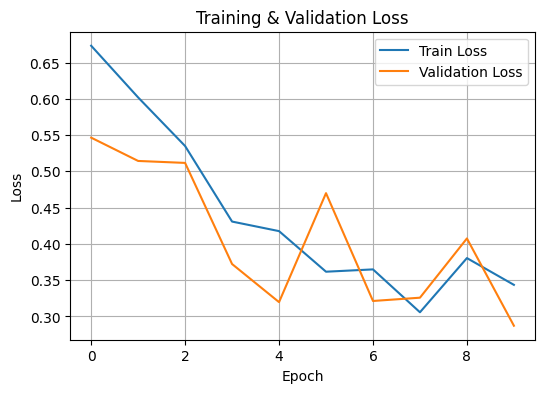

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


Test Accuracy: 88.86%
              precision    recall  f1-score   support

           Z       0.80      0.91      0.85       380
           O       0.89      0.77      0.82       380
           S       0.98      0.99      0.99       380

    accuracy                           0.89      1140
   macro avg       0.89      0.89      0.89      1140
weighted avg       0.89      0.89      0.89      1140



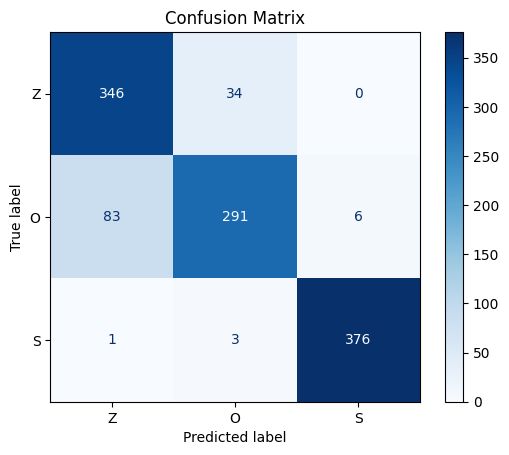

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

# Accuracy
accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test Accuracy: {accuracy:.2f}%")

# Classification report
print(classification_report(y_true, y_pred, target_names=["Z", "O", "S"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Z","O","S"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [21]:
print("Final Dataset Shape:", X.shape)
print("Classes distribution:", np.unique(y, return_counts=True))
print("Training completed successfully ✅")


Final Dataset Shape: (5700, 400)
Classes distribution: (array([0, 1, 2]), array([1900, 1900, 1900]))
Training completed successfully ✅
